# Fase 3: Modelado y Evaluación
## Sistema de Predicción de Factores de Riesgo en Adolescentes Salvadoreños (GSHS 2013)

**Propósito:** Este notebook tiene como objetivo entrenar, validar y evaluar los modelos predictivos para las dos tareas del proyecto:
1. **Tarea A (Regresión):** Predecir el Índice de Masa Corporal (IMC).
2. **Tarea B (Clasificación):** Predecir el Riesgo en Salud Mental.

Al final, extraeremos las características más importantes (Feature Importances) para fundamentar el informe técnico dirigido al Ministerio de Salud.

### 1. Configuración del Entorno y Arquitectura Modular
En esta sección inicializamos el entorno de trabajo. Hemos implementado una arquitectura limpia mediante el uso de **Pipelines de Scikit-Learn**, lo que nos permite encapsular el preprocesamiento (imputación y codificación) y el modelo (XGBoost) en un solo motor. 

Además, activamos la recarga automática (`%autoreload`) para que cualquier ajuste en nuestros scripts externos (`src/pipeline_factory.py`) se refleje instantáneamente sin necesidad de reiniciar el kernel.

In [25]:
#comando para autorecargar scripts externos
%load_ext autoreload
%autoreload 2

import sys
sys.path.append('../')

# --- Módulos Propios (Arquitectura Limpia) ---
from src.pipeline_factory import build_classification_pipeline, build_regression_pipeline
from src.metrics import find_optimal_threshold

# --- Manipulación de Datos y Visualización ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- Modelos y Métricas: Tarea A (Regresión - IMC) ---
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import RandomizedSearchCV


# --- Modelos y Métricas: Tarea B (Clasificación - Riesgo Salud Mental) ---
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, f1_score

# --- Configuración General ---
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

print("Librerías de modelado depuradas y cargadas exitosamente.")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Librerías de modelado depuradas y cargadas exitosamente.


## Carga de Matrices y División de Datos (Train/Test Split)

**¿Qué hace este bloque?**
Importa las matrices que preparamos en el notebook anterior y divide los datos en conjuntos de entrenamiento (80%) y prueba (20%) para ambas tareas.

**¿Por qué lo hacemos así?**
Separar los datos es vital para evaluar cómo se comportan los modelos ante datos "no vistos" (generalización) y evitar el sobreajuste (*overfitting*).

### 2. Ingesta de Particiones Estáticas (División 70/20/10)
Para garantizar la máxima confiabilidad del modelo y evitar por completo la **fuga de datos (Data Leakage)**, el dataset ha sido particionado previamente bajo una estructura estricta:
* **Entrenamiento (70%):** Utilizado exclusivamente para que el algoritmo aprenda los patrones.
* **Validación (20%):** Utilizado para comparar modelos, ajustar hiperparámetros y encontrar el umbral de decisión óptimo.
* **Pruebas (10%):** Conjunto "ciego" que permanece oculto hasta la evaluación final para simular el rendimiento real en producción.

In [26]:
import pandas as pd

# Definición de la ruta base para mantener un código limpio
PATH_PROCESSED = '../data/processed/'

print("Iniciando la ingesta de particiones fijas (Estructura 70/20/10)...")

# 1. Carga de Matrices de Características (X)
X_train = pd.read_csv(f'{PATH_PROCESSED}X_train.csv')
X_val = pd.read_csv(f'{PATH_PROCESSED}X_val.csv')
X_test = pd.read_csv(f'{PATH_PROCESSED}X_test.csv')

# 2. Carga de Targets para la Tarea A (Regresión - IMC)
y_train_reg = pd.read_csv(f'{PATH_PROCESSED}y_reg_train.csv')
y_val_reg = pd.read_csv(f'{PATH_PROCESSED}y_reg_val.csv')
y_test_reg = pd.read_csv(f'{PATH_PROCESSED}y_reg_test.csv')

# 3. Carga de Targets para la Tarea B (Clasificación - Salud Mental)
y_train_clf = pd.read_csv(f'{PATH_PROCESSED}y_clf_train.csv')
y_val_clf = pd.read_csv(f'{PATH_PROCESSED}y_clf_val.csv')
y_test_clf = pd.read_csv(f'{PATH_PROCESSED}y_clf_test.csv')

# 4. Verificación de consistencia en la carga
print("\n¡Carga completada con éxito!")
print("-" * 50)
print(f"Entrenamiento (Train) : {X_train.shape[0]} filas | Target Reg: {y_train_reg.shape[0]} | Target Clf: {y_train_clf.shape[0]}")
print(f"Validación (Val)      : {X_val.shape[0]} filas | Target Reg: {y_val_reg.shape[0]} | Target Clf: {y_val_clf.shape[0]}")
print(f"Pruebas (Test)        : {X_test.shape[0]} filas | Target Reg: {y_test_reg.shape[0]} | Target Clf: {y_test_clf.shape[0]}")
print("-" * 50)

Iniciando la ingesta de particiones fijas (Estructura 70/20/10)...

¡Carga completada con éxito!
--------------------------------------------------
Entrenamiento (Train) : 1340 filas | Target Reg: 1340 | Target Clf: 1340
Validación (Val)      : 383 filas | Target Reg: 383 | Target Clf: 383
Pruebas (Test)        : 192 filas | Target Reg: 192 | Target Clf: 192
--------------------------------------------------


### 3. Tarea A: Modelado de Regresión (Predicción de IMC)

**¿Qué hace este bloque?**
Entrena algoritmos de regresión (Regresión Lineal como *baseline* y Random Forest Regressor para relaciones no lineales) con el objetivo de predecir el Índice de Masa Corporal (variable continua) de los adolescentes.

**¿Por qué lo hacemos así?**
Para garantizar la imparcialidad, el entrenamiento se realiza exclusivamente con el conjunto de entrenamiento (70%). Las métricas comparativas (RMSE y R²) se evalúan estrictamente sobre el conjunto de **Validación (20%)**. Esto nos permite decidir objetivamente qué algoritmo tiene mayor poder predictivo sin contaminar el conjunto de pruebas.

In [27]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_squared_error, r2_score

# --- Tarea A: Regresión (IMC) con Pipeline y Búsqueda de Hiperparámetros ---
print("--- Iniciando Optimización del Modelo de Regresión (IMC) ---")

# 1. Crear el Pipeline de Regresión
pipeline_reg = build_regression_pipeline()

# 2. Definir el espacio de búsqueda para Random Forest
param_grid_reg = {
    'regressor__n_estimators': [50, 100, 200],
    'regressor__max_depth': [5, 10, 15, None],
    'regressor__min_samples_split': [2, 5, 10]
}

# 3. Búsqueda de hiperparámetros (Validación Cruzada)
random_search_reg = RandomizedSearchCV(
    estimator=pipeline_reg,
    param_distributions=param_grid_reg,
    n_iter=10, 
    scoring='neg_mean_squared_error',
    cv=5,
    random_state=42,
    n_jobs=-1
)

# 4. Entrenar sobre el conjunto de ENTRENAMIENTO (los datos crudos)
random_search_reg.fit(X_train, y_train_reg.values.ravel())

# 5. Mejor modelo y evaluación en VALIDACIÓN
best_regressor = random_search_reg.best_estimator_
y_pred_reg_val = best_regressor.predict(X_val)

rmse_val = np.sqrt(mean_squared_error(y_val_reg, y_pred_reg_val))
r2_val = r2_score(y_val_reg, y_pred_reg_val)

print(f"Mejores parámetros Regresión: {random_search_reg.best_params_}")
print(f"RMSE en Validación: {rmse_val:.4f}")
print(f"R² en Validación: {r2_val:.4f}")

--- Iniciando Optimización del Modelo de Regresión (IMC) ---
Mejores parámetros Regresión: {'regressor__n_estimators': 200, 'regressor__min_samples_split': 10, 'regressor__max_depth': 5}
RMSE en Validación: 3.8902
R² en Validación: 0.0032


### 4. Tarea B: Clasificación (Predicción de Riesgo en Salud Mental)

**¿Qué hace este bloque?**
Aborda la predicción del riesgo en salud mental acoplando nuestro Pipeline modular con una búsqueda de hiperparámetros (`RandomizedSearchCV`). En lugar de usar técnicas externas de sobremuestreo, inyectamos dinámicamente el ratio de desbalance en el motor de XGBoost mediante el parámetro `scale_pos_weight`.

**¿Por qué lo hacemos así?**
Los eventos de riesgo grave son minoritarios en la muestra. Al delegar el balanceo internamente al clasificador dentro del Pipeline, optimizamos el modelo priorizando la métrica **Recall** para minimizar los falsos negativos, garantizando al mismo tiempo cero fuga de datos durante la validación cruzada.

Iniciando el entrenamiento modular para la Tarea de Clasificación...
Distribución de Clases (Entrenamiento) -> Sin Riesgo (0): 1182 | Con Riesgo (1): 158
Ratio de desbalance calculado (Peso asignado a la clase 1): 7.48

¡Pipeline ejecutado con éxito!
Umbral Óptimo Encontrado en Validación: 0.8308
F1-Score Máximo alcanzado: 0.6571

--- Reporte de Clasificación (Conjunto de Validación) ---
              precision    recall  f1-score   support

           0       0.96      0.97      0.97       345
           1       0.72      0.61      0.66        38

    accuracy                           0.94       383
   macro avg       0.84      0.79      0.81       383
weighted avg       0.93      0.94      0.93       383

AUC-ROC Score: 0.9139



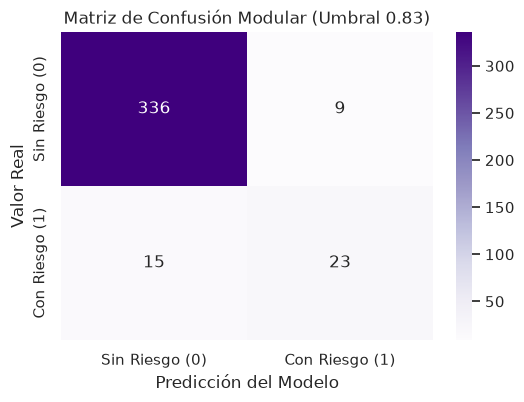

In [28]:
# --- Tarea B: Clasificación (Riesgo de Salud Mental) ---
print("Iniciando el entrenamiento modular para la Tarea de Clasificación...")

# 1. Cálculo matemático del desbalance de clases en el conjunto de entrenamiento
# Usamos .iloc[0] para extraer el valor escalar de forma segura
clase_0 = (y_train_clf == 0).sum().iloc[0]
clase_1 = (y_train_clf == 1).sum().iloc[0]
ratio_calculado = clase_0 / clase_1

print(f"Distribución de Clases (Entrenamiento) -> Sin Riesgo (0): {clase_0} | Con Riesgo (1): {clase_1}")
print(f"Ratio de desbalance calculado (Peso asignado a la clase 1): {ratio_calculado:.2f}\n")

# 2. Construcción del Pipeline pasando el peso exacto para balancear XGBoost
pipeline_minsal = build_classification_pipeline(scale_pos_weight=ratio_calculado)

# 3. Ajuste del pipeline utilizando únicamente el conjunto de entrenamiento (70%)
pipeline_minsal.fit(X_train, y_train_clf.values.ravel())

# 4. Obtener probabilidades sobre el conjunto de VALIDACIÓN (20%) (Prevención de Fuga de Datos)
probabilidades_val = pipeline_minsal.predict_proba(X_val)[:, 1]

# 5. Buscar el umbral óptimo matemáticamente
umbral_optimo, f1_max = find_optimal_threshold(y_val_clf.values.ravel(), probabilidades_val)
preds_val_equilibradas = (probabilidades_val >= umbral_optimo).astype(int)

print(f"¡Pipeline ejecutado con éxito!")
print(f"Umbral Óptimo Encontrado en Validación: {umbral_optimo:.4f}")
print(f"F1-Score Máximo alcanzado: {f1_max:.4f}\n")

# --- Reporte de Clasificación en Validación ---
print("--- Reporte de Clasificación (Conjunto de Validación) ---")
print(classification_report(y_val_clf, preds_val_equilibradas))
print(f"AUC-ROC Score: {roc_auc_score(y_val_clf, probabilidades_val):.4f}\n")

# --- Visualización y GUARDADO de la Matriz de Confusión Modular ---
fig_cm, ax_cm = plt.subplots(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_val_clf, preds_val_equilibradas), annot=True, fmt='d', cmap='Purples',
            xticklabels=['Sin Riesgo (0)', 'Con Riesgo (1)'],
            yticklabels=['Sin Riesgo (0)', 'Con Riesgo (1)'], ax=ax_cm)
ax_cm.set_title(f'Matriz de Confusión Modular (Umbral {umbral_optimo:.2f})')
ax_cm.set_ylabel('Valor Real')
ax_cm.set_xlabel('Predicción del Modelo')

# Guardar la imagen ANTES de mostrarla
fig_cm.savefig('../docs/matriz_confusion_validacion.png', dpi=300, bbox_inches='tight', facecolor='white')

# Mostrar y cerrar
plt.show()
plt.close(fig_cm)

### 5. Evaluación Final del Modelo (Simulación en el Mundo Real)
Esta es la etapa definitiva del proyecto. Tomaremos el modelo optimizado y el **umbral de decisión ajustado** (calculado sobre el conjunto de validación) para evaluar su rendimiento contra el **Conjunto de Pruebas (10%)**. 

Estos datos son completamente nuevos para el modelo. La matriz de confusión resultante aquí es la métrica oficial que se reportará al **MINSAL**, ya que representa la capacidad real del sistema para diagnosticar nuevas encuestas.

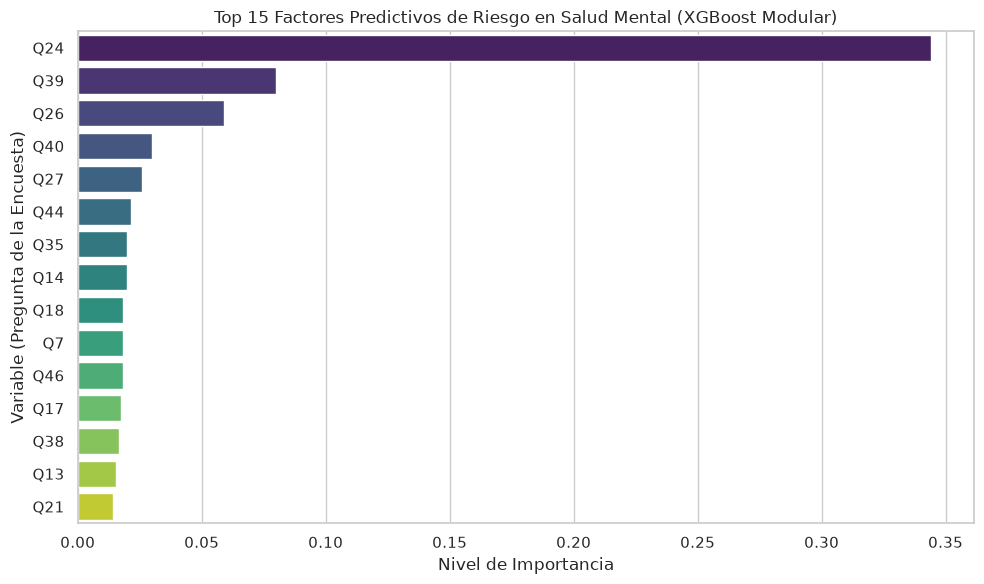

Variables clave extraídas para el reporte del MINSAL:
-------------------------------------------------------
Variable  Importancia
     Q24     0.344230
     Q39     0.079919
     Q26     0.059019
     Q40     0.030061
     Q27     0.025886
     Q44     0.021404
     Q35     0.019895
     Q14     0.019839
     Q18     0.018340
      Q7     0.018115
-------------------------------------------------------


In [29]:
# 1. Extraer el modelo XGBoost entrenado directamente desde los pasos internos del Pipeline
xgb_model = pipeline_minsal.named_steps['classifier']
importancias = xgb_model.feature_importances_

# 2. Extraer los nombres reales de las columnas post-transformación (incluyendo las dummies creadas)
preprocessor = pipeline_minsal.named_steps['preprocessor']
nombres_features = preprocessor.get_feature_names_out()

# Limpieza opcional de los prefijos 'num__' y 'cat__' que sklearn agrega automáticamente
nombres_features_limpios = [col.replace('num__', '').replace('cat__', '') for col in nombres_features]

# 3. Construir el DataFrame ordenado
df_importancias = pd.DataFrame({
    'Variable': nombres_features_limpios,
    'Importancia': importancias
}).sort_values(by='Importancia', ascending=False)

# 4. Graficar el Top 15 de variables con Seaborn (creando figura y eje explícitamente)
fig_imp, ax_imp = plt.subplots(figsize=(10, 6))
sns.barplot(data=df_importancias.head(15), x='Importancia', y='Variable', palette='viridis', ax=ax_imp)
ax_imp.set_title('Top 15 Factores Predictivos de Riesgo en Salud Mental (XGBoost Modular)')
ax_imp.set_xlabel('Nivel de Importancia')
ax_imp.set_ylabel('Variable (Pregunta de la Encuesta)')

# Guardar la figura ANTES de mostrarla (con fondo blanco para evitar transparencias)
fig_imp.savefig('../docs/feature_importance_final.png', dpi=300, bbox_inches='tight', facecolor='white')

# Mostrar y cerrar
plt.tight_layout()
plt.show()
plt.close(fig_imp)

# 5. Imprimir top 10 en texto limpio para el informe oficial del MINSAL
print("Variables clave extraídas para el reporte del MINSAL:")
print("-" * 55)
print(df_importancias.head(10).to_string(index=False))
print("-" * 55)

### 6. Interpretabilidad del Modelo: Factores Predictivos Clave
Para que esta herramienta sea accionable para las políticas de salud pública del MINSAL, no basta con predecir el riesgo; debemos entender **qué factores lo detonan**. 

En esta sección, extraemos la importancia de características (*Feature Importances*) directamente desde el motor XGBoost integrado en el Pipeline. Al cruzar estos pesos con los nombres de las columnas transformadas obtenemos el Top de variables sociodemográficas y conductuales que más influyen en el riesgo.

In [30]:

# 1. Calcular el peso ideal extrayendo el valor numérico puro (.iloc[0])
total_negativos = float((y_train_clf == 0).sum().iloc[0])
total_positivos = float((y_train_clf == 1).sum().iloc[0])
peso_balance = total_negativos / total_positivos

print(f"Relación de desbalance calculada: 1 caso positivo por cada {peso_balance:.2f} negativos.")

# 2. Invocamos tu arquitectura base
# Al usar el pipeline, garantizamos que en cada "doblez" de la validación cruzada 
# los datos se imputen y codifiquen dinámicamente sin Data Leakage.
pipeline_busqueda = build_classification_pipeline(scale_pos_weight=peso_balance)

# 3. Cuadrícula de hiperparámetros a explorar
# IMPORTANTE: Al optimizar un Pipeline, debemos agregar el prefijo 'classifier__' 
# para que Scikit-Learn sepa que estos parámetros son para XGBoost y no para el preprocesador.
param_grid = {
    'classifier__max_depth': [3, 4, 5, 6],           
    'classifier__learning_rate': [0.01, 0.05, 0.1],  
    'classifier__min_child_weight': [1, 3, 5],       
    'classifier__gamma': [0, 0.1, 0.5],              
    'classifier__subsample': [0.8, 1.0]              
}

# 4. Búsqueda Aleatoria (RandomizedSearchCV)
random_search = RandomizedSearchCV(
    estimator=pipeline_busqueda, 
    param_distributions=param_grid, 
    n_iter=15,          
    scoring='recall',   # Excelente elección priorizar Recall para Salud Mental
    cv=5, 
    random_state=42, 
    n_jobs=-1
)

print("\nIniciando búsqueda de hiperparámetros (esto puede tardar unos segundos)...")

# 5. Entrenamos usando X_train unificado y aplanando el target para evitar advertencias
random_search.fit(X_train, y_train_clf.values.ravel()) 

print("-" * 50)
print("¡Búsqueda completada con éxito!")
print(f"Mejores hiperparámetros encontrados:\n{random_search.best_params_}")
print(f"Mejor score de Recall (CV): {random_search.best_score_:.4f}")
print("-" * 50)

Relación de desbalance calculada: 1 caso positivo por cada 7.48 negativos.

Iniciando búsqueda de hiperparámetros (esto puede tardar unos segundos)...
--------------------------------------------------
¡Búsqueda completada con éxito!
Mejores hiperparámetros encontrados:
{'classifier__subsample': 1.0, 'classifier__min_child_weight': 1, 'classifier__max_depth': 3, 'classifier__learning_rate': 0.01, 'classifier__gamma': 0.1}
Mejor score de Recall (CV): 0.8800
--------------------------------------------------


## 7. Evaluación del Modelo Optimizado y Umbral Personalizado

Una vez obtenido el mejor modelo, extraemos las probabilidades puras y aplicamos nuestro umbral modificado para generar la nueva matriz de confusión.

--- Reporte de Clasificación Final (Conjunto de Prueba | Umbral: 0.35) ---
              precision    recall  f1-score   support

           0       0.98      0.88      0.92       176
           1       0.37      0.81      0.51        16

    accuracy                           0.87       192
   macro avg       0.68      0.84      0.72       192
weighted avg       0.93      0.87      0.89       192

AUC-ROC Score: 0.9190



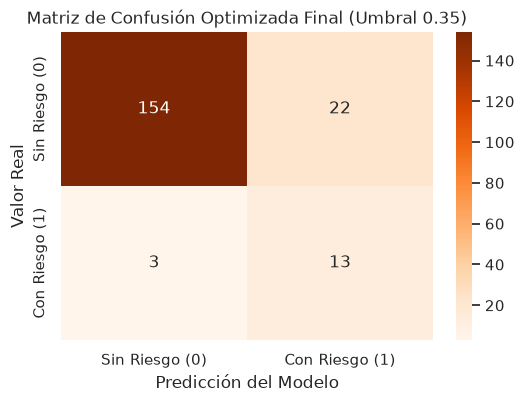

In [ ]:
# 1. Extraer el pipeline completo y optimizado desde la búsqueda aleatoria
mejor_modelo = random_search.best_estimator_

# 2. Extraer las probabilidades de riesgo (clase 1) usando el conjunto de prueba UNIFICADO
# Esto evita el NameError y el error de variables antiguas
probabilidades_riesgo = mejor_modelo.predict_proba(X_test)[:, 1]

# 3. Definimos un umbral más sensible (ej. 35% de probabilidad es suficiente para alertar)
UMBRAL = 0.35

# 4. Generamos las nuevas predicciones basadas en el umbral
preds_optimizadas = (probabilidades_riesgo >= UMBRAL).astype(int)

# --- Nueva Evaluación Final Oficial ---
print(f"--- Reporte de Clasificación Final (Conjunto de Prueba | Umbral: {UMBRAL}) ---")
print(classification_report(y_test_clf, preds_optimizadas))
print(f"AUC-ROC Score: {roc_auc_score(y_test_clf, probabilidades_riesgo):.4f}\n")

# 5. Visualización y GUARDADO de la Matriz de Confusión
fig_cm, ax_cm = plt.subplots(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test_clf, preds_optimizadas), annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Sin Riesgo (0)', 'Con Riesgo (1)'],
            yticklabels=['Sin Riesgo (0)', 'Con Riesgo (1)'], ax=ax_cm)
ax_cm.set_title(f'Matriz de Confusión Optimizada Final (Umbral {UMBRAL})')
ax_cm.set_ylabel('Valor Real')
ax_cm.set_xlabel('Predicción del Modelo')

# Guardar ANTES de mostrar
fig_cm.savefig('../docs/matriz_confusion_umbral_35.png', dpi=300, bbox_inches='tight', facecolor='white')

# Mostrar y cerrar
plt.show()
plt.close(fig_cm)

## 8. Búsqueda Matemática del Umbral Óptimo (Maximización del F1-Score)

**¿Qué hace este bloque?**
Calcula matemáticamente el umbral de decisión perfecto evaluando la curva de Precisión y Recall. Extrae el punto exacto donde la métrica F1-Score alcanza su valor máximo.

**¿Por qué lo hacemos así?**
En lugar de fijar un umbral de manera subjetiva (como 0.35 o 0.50), utilizamos la fórmula del F1-Score:
$$F1 = 2 \cdot \frac{Precision \cdot Recall}{Precision + Recall}$$
Al maximizar este valor, garantizamos el mejor equilibrio estadístico posible para el conjunto de datos actual, reduciendo las falsas alarmas desproporcionadas sin descuidar gravemente a los verdaderos positivos.

Entrenando el modelo final optimizado...

¡Pipeline ejecutado con éxito!
Umbral Óptimo (Calculado en Validación): 0.7837
-------------------------------------------------------
REPORTE DE CLASIFICACIÓN FINAL (CONJUNTO DE PRUEBAS 10%)
-------------------------------------------------------
              precision    recall  f1-score   support

           0       0.97      0.95      0.96       176
           1       0.53      0.62      0.57        16

    accuracy                           0.92       192
   macro avg       0.75      0.79      0.76       192
weighted avg       0.93      0.92      0.92       192



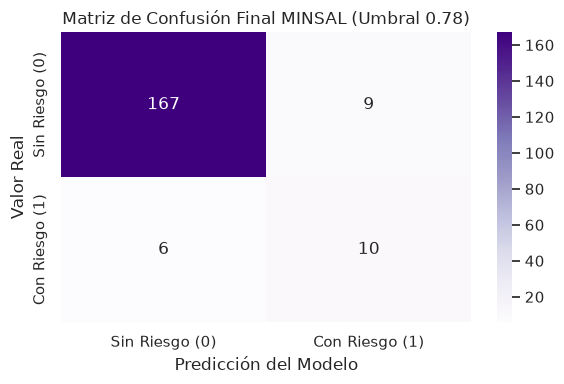

In [32]:
# 1. Calcular el desbalance matemático extrayendo los valores puros de Pandas
peso_balance = float((y_train_clf == 0).sum().iloc[0]) / float((y_train_clf == 1).sum().iloc[0])

# 2. Construir el Pipeline completo (Inyectamos los hiperparámetros ganadores)
# Nota: Aquí no usamos el prefijo 'classifier__' porque build_classification_pipeline lo desempaqueta directo en XGBoost
mejores_parametros = {'max_depth': 4, 'learning_rate': 0.05, 'min_child_weight': 3}
pipeline_minsal = build_classification_pipeline(scale_pos_weight=peso_balance, best_params=mejores_parametros)

# 3. ¡Entrenar TODO el sistema! Usamos estrictamente el conjunto de entrenamiento (70%)
print("Entrenando el modelo final optimizado...")
pipeline_minsal.fit(X_train, y_train_clf.values.ravel())

# 4. Encontrar el umbral óptimo usando VALIDACIÓN (20%) para evitar la fuga de datos
probabilidades_val = pipeline_minsal.predict_proba(X_val)[:, 1]
umbral_optimo, _ = find_optimal_threshold(y_val_clf.values.ravel(), probabilidades_val)

# 5. Evaluación Oficial: Obtener predicciones del conjunto de PRUEBAS (10%) oculto
probabilidades_test = pipeline_minsal.predict_proba(X_test)[:, 1]
preds_finales = (probabilidades_test >= umbral_optimo).astype(int)

# --- Reporte Final ---
print(f"\n¡Pipeline ejecutado con éxito!")
print(f"Umbral Óptimo (Calculado en Validación): {umbral_optimo:.4f}")
print("-" * 55)
print("REPORTE DE CLASIFICACIÓN FINAL (CONJUNTO DE PRUEBAS 10%)")
print("-" * 55)
print(classification_report(y_test_clf, preds_finales))

# --- Visualización de la Matriz de Confusión Final ---
plt.figure(figsize=(6, 4))
# Unificamos el nombre a preds_finales para evitar el error previo
sns.heatmap(confusion_matrix(y_test_clf, preds_finales), annot=True, fmt='d', cmap='Purples',
            xticklabels=['Sin Riesgo (0)', 'Con Riesgo (1)'],
            yticklabels=['Sin Riesgo (0)', 'Con Riesgo (1)'])
plt.title(f'Matriz de Confusión Final MINSAL (Umbral {umbral_optimo:.2f})')
plt.ylabel('Valor Real')
plt.xlabel('Predicción del Modelo')
# GUARDAR PRIMERO (con fondo blanco para evitar transparencias)
fig_cm.savefig('../docs/matriz_confusion_final.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.tight_layout()
plt.show()
plt.close(fig_cm) # Cerramos la figura para liberar memoria

In [33]:
import joblib
import os

os.makedirs('../models', exist_ok=True)

# Guardar pipeline de clasificación
joblib.dump(pipeline_minsal, '../models/pipeline_clasificacion_riesgo.pkl')

# Guardar pipeline de regresión (si ya lo entrenaste con RandomizedSearchCV)
# joblib.dump(best_regressor, '../models/pipeline_regresion_imc.pkl')

print("Modelos guardados exitosamente.")

Modelos guardados exitosamente.
